In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos
from math import log
from scipy.interpolate import interp1d
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from scipy.optimize import fsolve
from sympy import symbols, Eq, solve

In [2]:
#climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")

#### Initial testing, based on the parameters used by Parham & Michael (2010)

In [4]:
#### Article parameters:

T_prime=19.9

T1=23.2
T2=0.07
omega1=0.67
phi1=1.53

R1=85.9
R2=0.98
omega2=0.65
phi2=1.99

B_E=200
p_ME=0.9
p_ML=0.25
p_MP=0.75
tau_E=1
tau_P=1
c1=0.00554
c2=-0.06737
D1=36.5
b1=0.04
b2=0.09
A=-0.03
B=1.31
C=-4.4
tau_H=10
DD=105
Tmin=14.5
gamma= 1/120
R_L = 50
N=8558
M= 1000

E_M0=500
I_H0=1000

if E_M0 is None:
        E_M0 = M / 100

S_H0 = N - I_H0
S_M0 = M - E_M0

In [5]:
def Temp(t):
       return T1 * (1 + T2 * cos(omega1 * t - phi1))

def Rain(t):
       return R1 * (1 + R2 * cos(omega2 * t - phi2))

In [6]:
def original_model(t, z, history, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
                   D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
                   N, M):

    S_H, I_H, R_H, S_M, E_M, I_M = z

    # Get the closest integer day
    day_index = int(t)
    # if day_index >= len(df):
    #     day_index = len(df) - 1

    T_curr = Temp(day_index)
    R_curr = Rain(day_index)

    # Temperature dependent quantities
    def tau_L(Temp):
        return 1 / (c1 * Temp + c2)

    def p(Temp):
        return np.exp(-1 / (A * Temp**2 + B * Temp + C))

    def p_LT(Temp):
        return np.exp(-(c1 * Temp + c2))

    def p_LR(Rain):
        return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

    def p_LRT(Rain, Temp):
        return p_LR(Rain) * p_LT(Temp)

    def p_ER(Rain):
        return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

    def p_PR(Rain):
        return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

    def tau_M(Temp):
        return DD / (Temp - Tmin)

    tau_M_curr = tau_M(T_curr)

    def l_tau_M(tau_M, Temp):
        p_T = p(Temp)
        return p_T**tau_M

    l_curr = l_tau_M(tau_M_curr, T_curr)

    def mu(Temp):
        return -np.log(p(Temp))

    mu_curr = mu(T_curr)

    def a(Temp):
        return (Temp - T_prime) / D1

    a_curr = a(T_curr)

    def b(Rain, Temp):
        return B_E * p_ER(Rain) * p_LRT(Rain, Temp) * p_PR(Rain) / (tau_E + tau_L(Temp) + tau_P)

    b_curr = b(R_curr, T_curr)

    # ----- DELAYED STATES -----

    S_H_delay, I_H_delay, R_H_delay, S_M_delay, E_M_delay, I_M_delay = history(t - tau_H)
    S_H_delay_M, I_H_delay_M, R_H_delay_M, S_M_delay_M, E_M_delay_M, I_M_delay_M = history(t - tau_M_curr)

    # ----- HUMAN EQUATIONS -----

    dShdt = -a_curr * b2 * (I_M / N) * S_H

    dIhdt = (
        a_curr * b2 * (I_M_delay / N) * S_H_delay
        - gamma * I_H
    )

    dRhdt = gamma * I_H

    # ----- MOSQUITO EQUATIONS -----

    dSmdt = b_curr - a_curr * b1 * (I_H / N) * S_M - mu_curr * S_M

    dEmdt = (
        a_curr * b1 * (I_H / N) * S_M
        - a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr
        - mu_curr * E_M
    )

    dImdt = (
        a_curr * b1 * (I_H_delay_M / N) * S_M_delay_M * l_curr
        - mu_curr * I_M
    )

    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [7]:
initial_state = np.array([S_H0, I_H0, 0, S_M0, E_M0, 0])

In [8]:
def history(t):
    return initial_state

In [9]:
args = (history, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M)

In [10]:
t_eval = np.arange(0, 3289, 0.1)  # 0.1 day steps

sol = solve_ivp(
    original_model,
    [0, 3289],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="DOP853"
)

In [11]:
def history(t):
    if t <= 0:
        return initial_state
    return sol.sol(t)

In [12]:
times = sol.t
S_H, I_H, R_H, S_M, E_M, I_M = sol.y

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


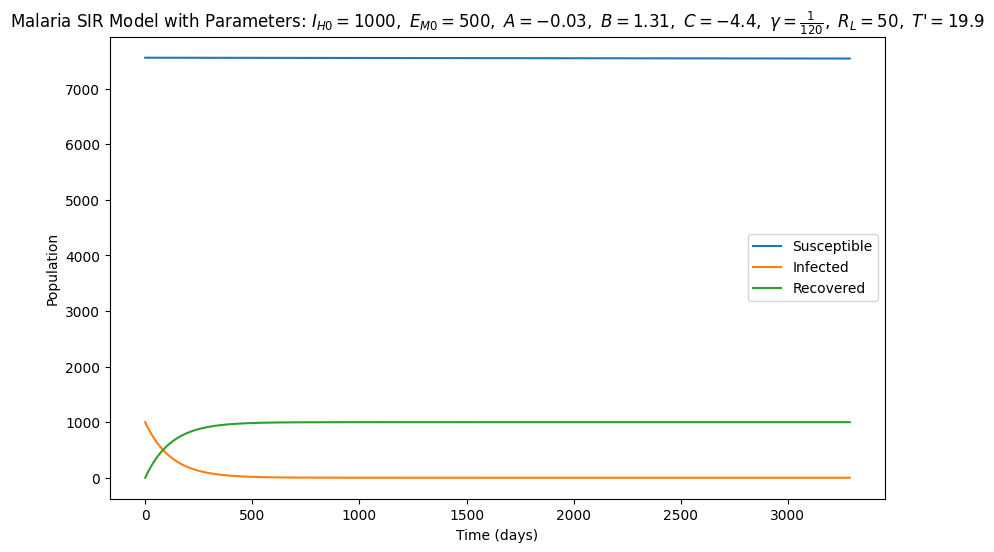

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(
    rf"Malaria SIR Model with Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()

plt.show()

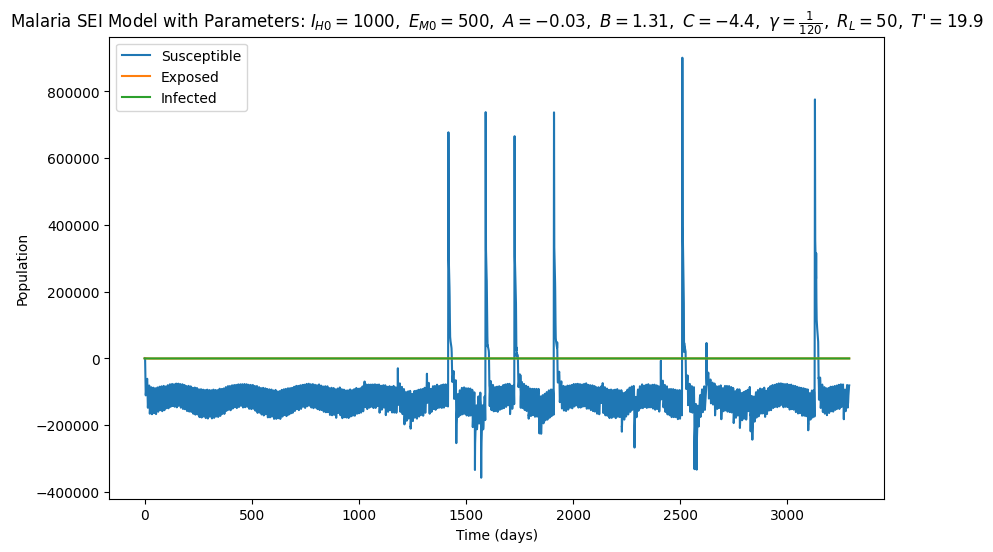

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(rf"Malaria SEI Model with Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()

plt.show()